# Day 04 — Data Cleaning & Feature Engineering
**Member 2** | Goal: Clean raw data and build weather features per growth stage

## Objectives
- Run cleaning pipeline → `clean_cotton`, `clean_weather`
- Run feature engineering → `features`, `features_with_risk`
- Inspect growth stage feature distributions
- Validate no leakage in features table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import sys
sys.path.append('../src')
from config import DB_PATH, STAGES

con = duckdb.connect(DB_PATH)
print('Connected to DuckDB ✓')

Connected to DuckDB ✓


## 1. Run Cleaning Pipeline

In [2]:
from cleaning import run_cleaning
run_cleaning()

[2026-04-29 09:40:38] 
[2026-04-29 09:40:38] MEMBER 1 — DATA CLEANING PIPELINE
[2026-04-29 09:40:38] =======================================================
[2026-04-29 09:40:38] =======================================================
[2026-04-29 09:40:38] STEP 3 — Cleaning Cotton Dataset
[2026-04-29 09:40:38] =======================================================
[2026-04-29 09:40:38]    Rows loaded from raw_cotton: 725
[2026-04-29 09:40:38]    Null yields: 191
[2026-04-29 09:40:38] 
  Districts dropped (had null values):
[2026-04-29 09:40:38]     ✗ Agdash district
[2026-04-29 09:40:38]     ✗ Aghdara district
[2026-04-29 09:40:38]     ✗ Aghsu district
[2026-04-29 09:40:38]     ✗ Fuzuli district
[2026-04-29 09:40:38]     ✗ Ganja city
[2026-04-29 09:40:38]     ✗ Goychay district
[2026-04-29 09:40:38]     ✗ Hajigabul district
[2026-04-29 09:40:38]     ✗ Jabrayil district
[2026-04-29 09:40:38]     ✗ Jalilabad district
[2026-04-29 09:40:38]     ✗ Khojaly district
[2026-04-29 09:40:38]    

## 2. Inspect clean_cotton

In [3]:
df_cotton = con.execute("""
    SELECT region, year, yield_tonnes, weather_station
    FROM clean_cotton
    ORDER BY region, year
""").df()

print(f'Shape: {df_cotton.shape}')
print(f'Districts: {df_cotton.region.nunique()}')
print(f'Years: {df_cotton.year.min()} – {df_cotton.year.max()}')
print(f'Nulls: {df_cotton.isnull().sum().sum()}')
df_cotton.describe()

Shape: (375, 4)
Districts: 15
Years: 2000 – 2024
Nulls: 0


,year,yield_tonnes
count,375.000000,375.000000
mean,2012.000000,18.796000
std,7.220737,8.570829
min,2000.000000,1.000000
25%,2006.000000,12.150000
50%,2012.000000,17.200000
75%,2018.000000,25.600000
max,2024.000000,43.200000


## 3. Inspect clean_weather

In [4]:
df_weather = con.execute("""
    SELECT region, year, month,
           temp_mean, precipitation, humidity_mean, wind_speed
    FROM clean_weather
    LIMIT 5
""").df()
df_weather

,region,year,month,temp_mean,precipitation,humidity_mean,wind_speed
0,Aghdam district,2000,1,5.496000,0.000000,71.967415,6.151683
1,Aghdam district,2000,1,4.018917,0.000000,82.369150,6.849467
2,Aghdam district,2000,1,3.771000,2.200000,86.751840,6.519877
3,Aghdam district,2000,1,3.675167,10.899999,95.270424,7.895416
4,Aghdam district,2000,1,2.931417,5.700000,93.605070,9.931042


## 4. Run Feature Engineering

In [5]:
from features import run_features
run_features()

[2026-04-29 09:40:42] 
[2026-04-29 09:40:42] MEMBER 2 — FEATURE ENGINEERING PIPELINE
[2026-04-29 09:40:42] =======================================================
[2026-04-29 09:40:42] =======================================================
[2026-04-29 09:40:42] STEP 6 — Building Growth Stage Features
[2026-04-29 09:40:42] =======================================================
[2026-04-29 09:40:42]   Cotton rows:  375
[2026-04-29 09:40:42]   Weather rows: 142455
[2026-04-29 09:40:42]   Districts:    15
[2026-04-29 09:40:42]   Processing 375 district-year combinations...
[2026-04-29 09:40:43]   Processed 100/375 rows...
[2026-04-29 09:40:45]   Processed 200/375 rows...
[2026-04-29 09:40:46]   Processed 300/375 rows...
[2026-04-29 09:40:47] 
  Final shape:  (375, 44)
[2026-04-29 09:40:47]   Districts:    15
[2026-04-29 09:40:47]   Years:        2000 – 2024
[2026-04-29 09:40:47]   Null check:   0 nulls
[2026-04-29 09:40:47]   features → DuckDB ✓
[2026-04-29 09:40:47] ====================

## 5. Inspect features table

In [6]:
df_feat = con.execute('SELECT * FROM features').df()
print(f'Shape: {df_feat.shape}')
print(f'Columns: {list(df_feat.columns)}')
print(f'Nulls:   {df_feat.isnull().sum().sum()}')

# Confirm NO risk/label columns leaked in
forbidden = [c for c in df_feat.columns if any(k in c for k in ('risk','label','deviation'))]
if forbidden:
    print(f'LEAKAGE DETECTED: {forbidden}')
else:
    print('No leakage columns ✓')

Shape: (375, 44)
Columns: ['region', 'weather_station', 'year', 'yield_tonnes', 'planting_temp_mean', 'planting_heat_stress_days', 'planting_frost_days', 'planting_GDD', 'planting_total_rain', 'planting_rainy_days', 'planting_dry_days', 'planting_max_dry_streak', 'planting_humidity_mean', 'planting_wind_mean', 'growing_temp_mean', 'growing_heat_stress_days', 'growing_frost_days', 'growing_GDD', 'growing_total_rain', 'growing_rainy_days', 'growing_dry_days', 'growing_max_dry_streak', 'growing_humidity_mean', 'growing_wind_mean', 'boll_forming_temp_mean', 'boll_forming_heat_stress_days', 'boll_forming_frost_days', 'boll_forming_GDD', 'boll_forming_total_rain', 'boll_forming_rainy_days', 'boll_forming_dry_days', 'boll_forming_max_dry_streak', 'boll_forming_humidity_mean', 'boll_forming_wind_mean', 'harvest_temp_mean', 'harvest_heat_stress_days', 'harvest_frost_days', 'harvest_GDD', 'harvest_total_rain', 'harvest_rainy_days', 'harvest_dry_days', 'harvest_max_dry_streak', 'harvest_humidity_

## 6. Growth Stage Feature Distributions

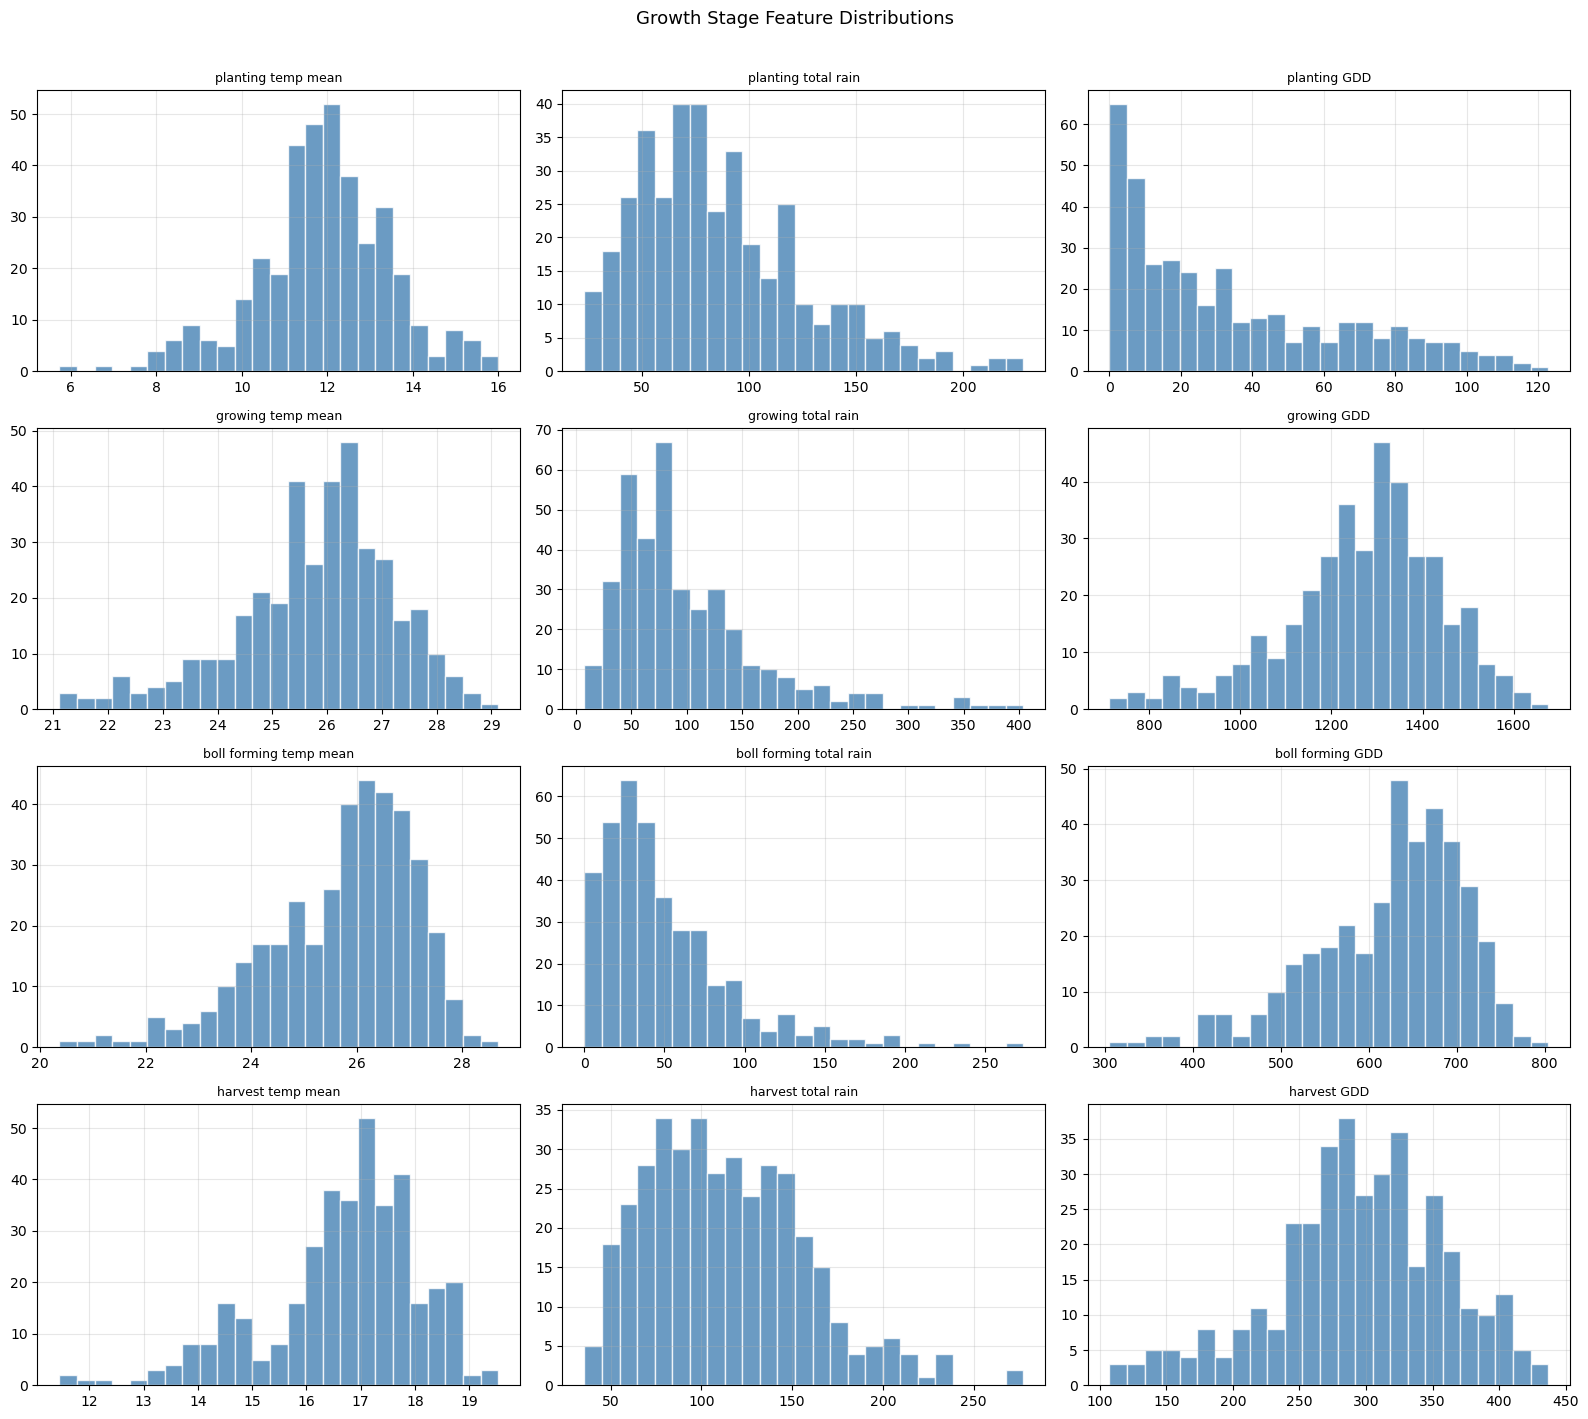

In [7]:
stages = ['planting', 'growing', 'boll_forming', 'harvest']
fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for row_idx, stage in enumerate(stages):
    cols_to_plot = [
        f'{stage}_temp_mean',
        f'{stage}_total_rain',
        f'{stage}_GDD'
    ]
    for col_idx, col in enumerate(cols_to_plot):
        ax = axes[row_idx][col_idx]
        if col in df_feat.columns:
            ax.hist(df_feat[col].dropna(), bins=25,
                    color='steelblue', edgecolor='white', alpha=0.8)
            ax.set_title(col.replace('_', ' '), fontsize=9)
            ax.set_xlabel('')
            ax.grid(True, alpha=0.3)

plt.suptitle('Growth Stage Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Risk Scores (features_with_risk)

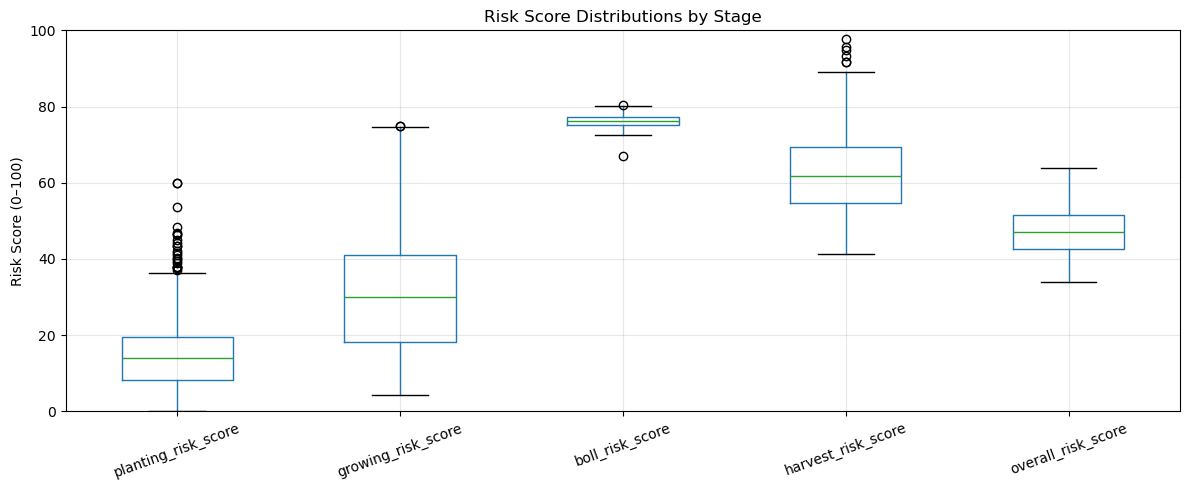

In [8]:
df_risk = con.execute('SELECT * FROM features_with_risk').df()
risk_cols = ['planting_risk_score','growing_risk_score',
             'boll_risk_score','harvest_risk_score','overall_risk_score']

fig, ax = plt.subplots(figsize=(12, 5))
df_risk[risk_cols].boxplot(ax=ax)
ax.set_title('Risk Score Distributions by Stage')
ax.set_ylabel('Risk Score (0–100)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8. Verify Risk Label Validation

In [9]:
avg_by_label = df_risk.groupby('overall_risk_label')['yield_tonnes'].mean()
print('Average yield by risk label:')
print(f'  Safe  (0): {avg_by_label.get(0, 0):.2f} tonnes')
print(f'  Risky (1): {avg_by_label.get(1, 0):.2f} tonnes')
status = '✓ PASSED' if avg_by_label.get(0,0) > avg_by_label.get(1,0) else '✗ WARNING'
print(f'  Validation: {status}')

con.close()

Average yield by risk label:
  Safe  (0): 23.39 tonnes
  Risky (1): 11.18 tonnes
  Validation: ✓ PASSED


## Summary
- `clean_cotton` and `clean_weather` created ✓
- `features` table: 40 weather features × 4 stages, no leakage ✓
- `features_with_risk` table: risk scores computed from weather only ✓
- **Next:** `day_05_checkpoint.ipynb` — quality checks before modelling